# Fase 6: Tecniche di Machine Learning Interpretabile (XAI) per la Valutazione del Rischio Cardiovascolare

In questa analisi finale utilizzeremo diverse tecniche di **Explainable AI (XAI)** per interpretare le decisioni del miglior modello clinico selezionato (la **Regressione Logistica** addestrata sul dataset sbilanciato `Clean + Aug`).

L'obiettivo è comprendere il comportamento del modello sia a livello globale (quali variabili contano di più complessivamente) sia a livello locale (perché un singolo paziente ha ricevuto una specifica predizione).

Confronteremo tre tecniche chiave:
1. **Permutation Feature Importance (PFI)**: Misura l'importanza globale delle feature in base alla perdita di performance del modello (in termini di Recall clinico) quando i valori di una variabile vengono mescolati casualmente sul Test Set.
2. **Partial Dependence Plots (PDP)**: Mostrano la relazione funzionale (lineare o non lineare) tra una o due feature d'interesse e la probabilità predetta del rischio cardiovascolare.
3. **SHAP (SHapley Additive exPlanations)**: Basato sulla teoria dei giochi di Shapley, assegna a ciascuna feature un valore di importanza additiva che spiega la deviazione della predizione del singolo paziente rispetto al valore atteso medio del dataset. Fornisce interpretazioni sia globali che locali (waterfall plot).

In [1]:
# Importazione delle librerie per XAI e modellizzazione clinica
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Impostiamo lo stile grafico di Seaborn
sns.set_theme(style="whitegrid")

In [2]:
# Definizione dei percorsi per caricare il miglior modello selezionato (Clean + Aug, Logistic Regression)
PERCORSO_MODELLO = "../Training/Clean/Aug/logistic_regression.joblib"
CARTELLA_DATI = "../Training/Clean/Aug/"

# Caricamento del modello
print("🔄 Caricamento del modello...")
modello_xai = joblib.load(PERCORSO_MODELLO)

# Caricamento dei dati di training e test
X_train = pd.read_csv(os.path.join(CARTELLA_DATI, "X_train.csv"))
X_test = pd.read_csv(os.path.join(CARTELLA_DATI, "X_test.csv"))
y_test = pd.read_csv(os.path.join(CARTELLA_DATI, "Y_test.csv")).squeeze().values.ravel()

print(f"📦 Caricati dati correttamente! Train shape: {X_train.shape}, Test shape: {X_test.shape}")

🔄 Caricamento del modello...
📦 Caricati dati correttamente! Train shape: (4312, 15), Test shape: (848, 15)


## 1. Permutation Feature Importance (PFI)

Calcolo dell'importanza globale delle feature mescolando casualmente ciascuna colonna sul **Test Set** e misurando il decremento della metrica clinica **Recall** (la sensibilità nel rilevare soggetti a rischio). Se mescolando una variabile le performance crollano, quella variabile è fondamentale per il modello.

🚀 Calcolo del Permutation Feature Importance...


<string>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<string>:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


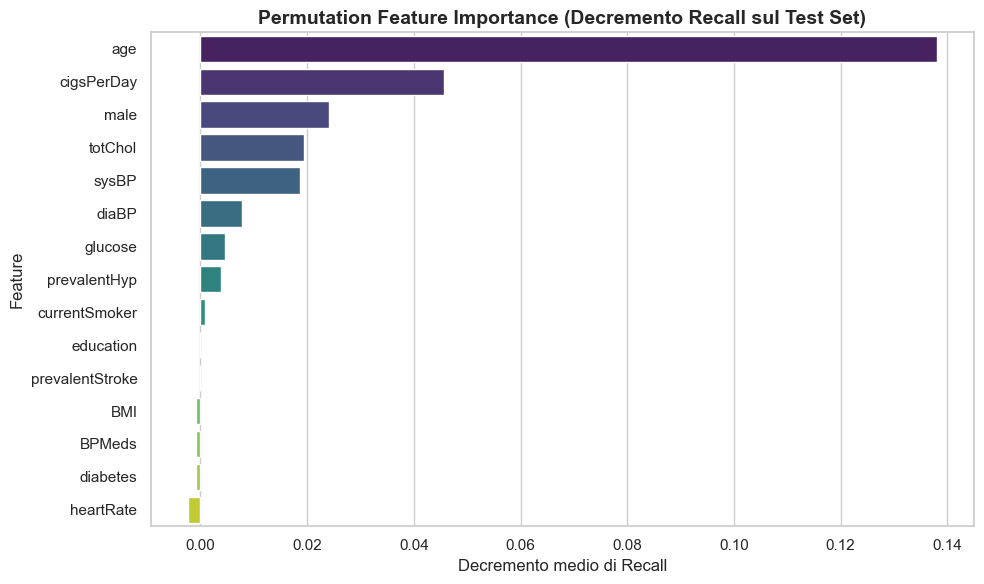

In [3]:
print("🚀 Calcolo del Permutation Feature Importance...")
risultati_pfi = permutation_importance(
    modello_xai, X_test, y_test, scoring='recall', n_repeats=10, random_state=42, n_jobs=-1
)

# Organizzazione dei risultati
tabella_pfi = pd.DataFrame({
    'Feature': X_test.columns,
    'Importanza_Media': risultati_pfi.importances_mean,
    'Importanza_Std': risultati_pfi.importances_std
}).sort_values(by='Importanza_Media', ascending=False)

# Plot dei risultati
plt.figure(figsize=(10, 6))
sns.barplot(data=tabella_pfi, x='Importanza_Media', y='Feature', palette='viridis')
plt.title('Permutation Feature Importance (Decremento Recall sul Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Decremento medio di Recall')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 2. Partial Dependence Plots (PDP)

I PDP ci permettono di visualizzare l'effetto marginale di una singola variabile sulla probabilità stimata di contrarre CHD (cardiopatia coronarica) a 10 anni. Analizziamo le principali variabili cliniche emerse dall'importanza delle feature (es. `age`, `sysBP`, `totChol`, `glucose`).

🚀 Generazione dei Partial Dependence Plots...


<string>:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


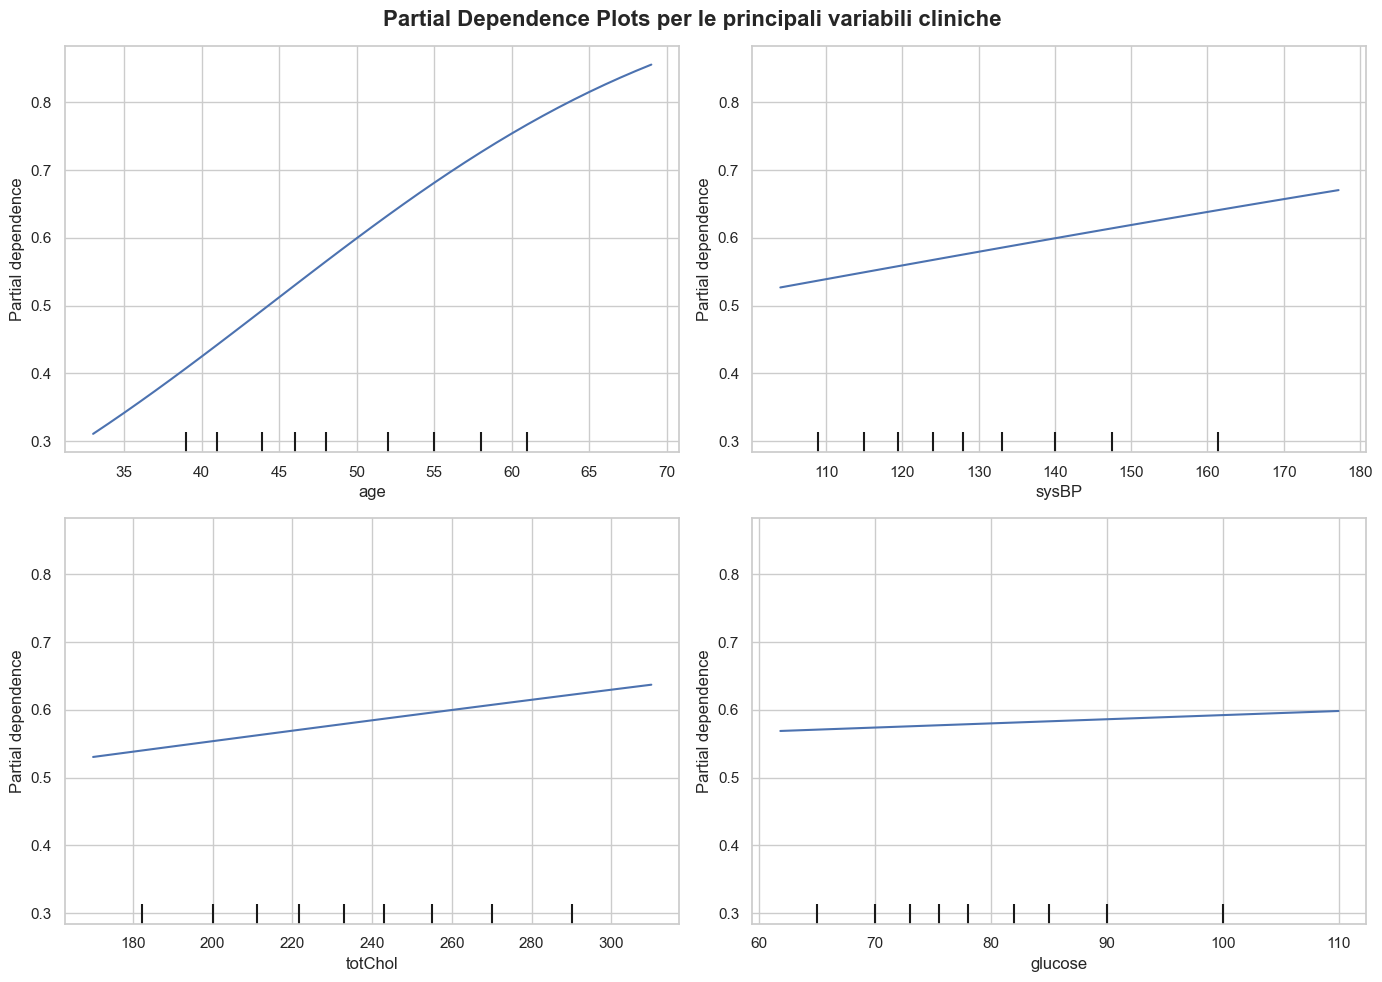

In [4]:
print("🚀 Generazione dei Partial Dependence Plots...")
variabili_da_analizzare = ['age', 'sysBP', 'totChol', 'glucose']

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
PartialDependenceDisplay.from_estimator(
    modello_xai, X_test, features=variabili_da_analizzare, ax=ax.ravel(), grid_resolution=50
)
plt.suptitle('Partial Dependence Plots per le principali variabili cliniche', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. SHAP (SHapley Additive exPlanations)

Utilizzo di SHAP per ottenere una spiegazione additiva basata sulla teoria dei giochi. Poiché stiamo interpretando un modello di **Regressione Logistica**, possiamo usare `shap.Explainer` che fornisce calcoli esatti utilizzando la covarianza dei dati di training come background.

🚀 Inizializzazione di SHAP Explainer...


Background dataset has 4312 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4312 when initializing the masker.
<string>:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


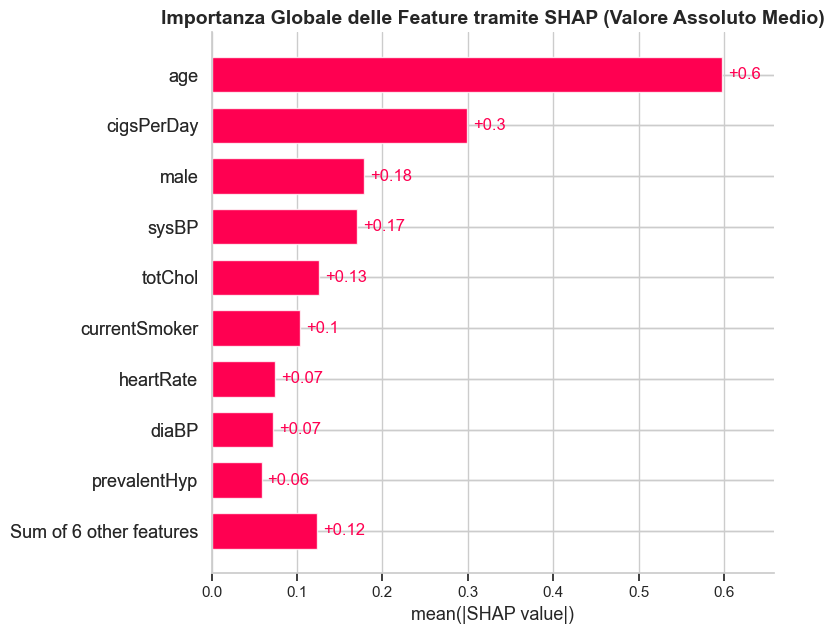

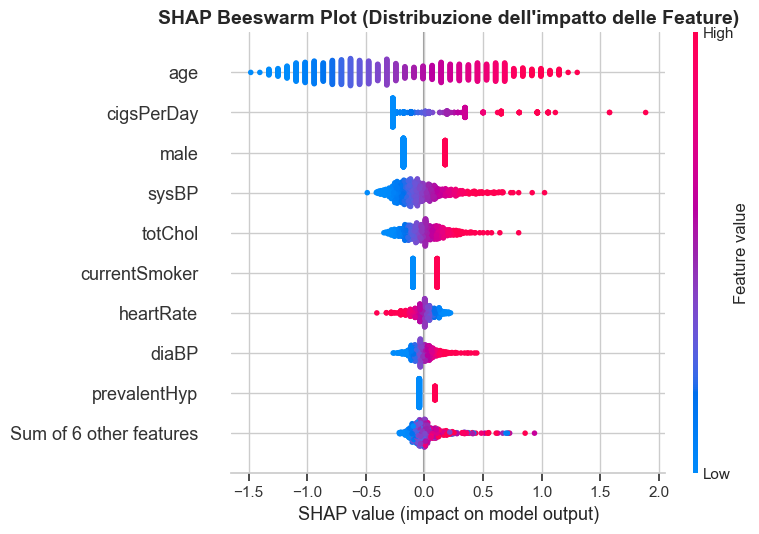

In [5]:
print("🚀 Inizializzazione di SHAP Explainer...")
# Utilizzo di una sintesi dei dati di train come background per l'indipendenza delle feature
explainer_shap = shap.Explainer(modello_xai, X_train)
valori_shap = explainer_shap(X_test)

# 3.1. SHAP Bar Plot (Importanza Globale)
plt.figure(figsize=(10, 6))
shap.plots.bar(valori_shap, show=False)
plt.title('Importanza Globale delle Feature tramite SHAP (Valore Assoluto Medio)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3.2. SHAP Beeswarm Plot (Summary Plot)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(valori_shap, show=False)
plt.title('SHAP Beeswarm Plot (Distribuzione dell\'impatto delle Feature)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Spiegazione Locale (Waterfall Plots per i pazienti a indice 2 e 36 del Test Set)

Selezione dei pazienti richiesti (indice 2 e indice 36) dal Test Set per visualizzare le spiegazioni locali tramite il **Waterfall Plot** di SHAP, evidenziando quali variabili cliniche spingono il rischio al di sopra o al di sotto della media.

🚀 Generazione dei Waterfall Plot per i pazienti ad indice 2 e 36 del Test Set...


<string>:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


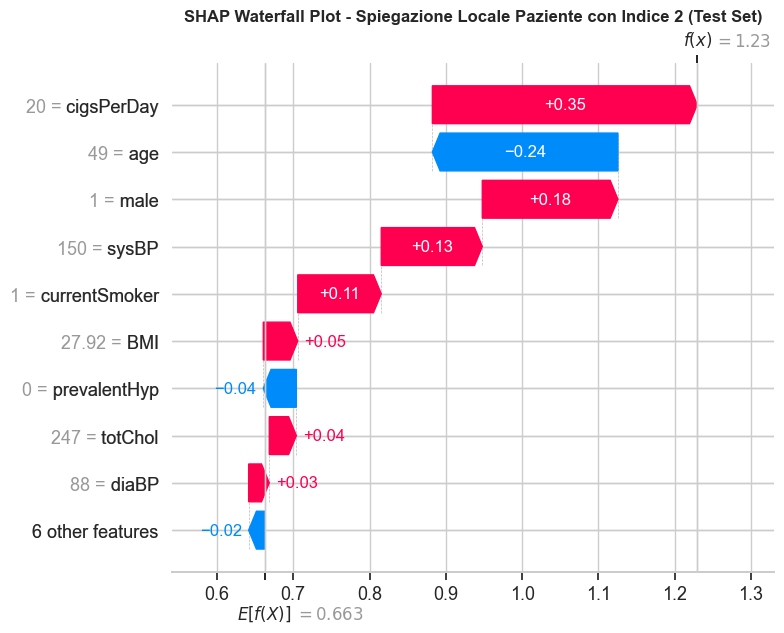

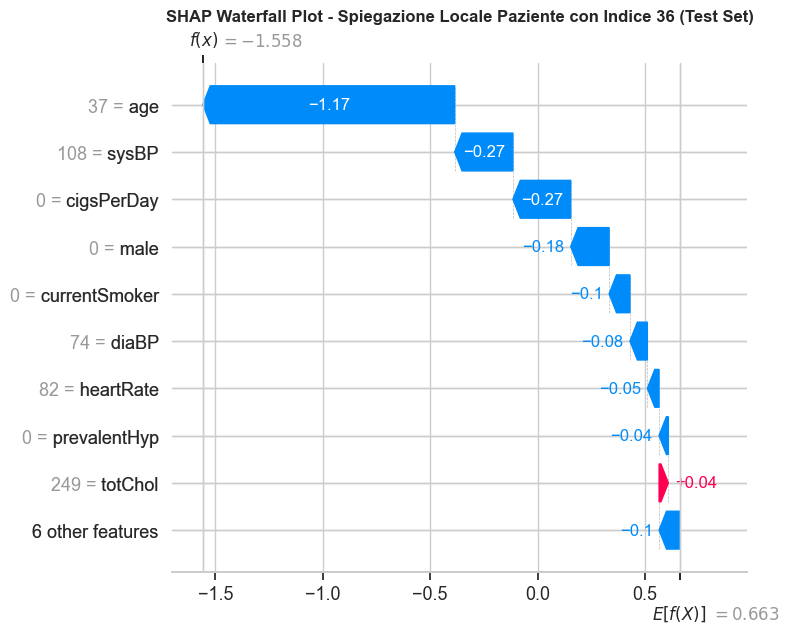

In [6]:
print("🚀 Generazione dei Waterfall Plot per i pazienti ad indice 2 e 36 del Test Set...")

# Visualizziamo la spiegazione locale per il paziente ad indice 2 nel Test Set
plt.figure(figsize=(10, 6))
shap.plots.waterfall(valori_shap[2], show=False)
plt.title('SHAP Waterfall Plot - Spiegazione Locale Paziente con Indice 2 (Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualizziamo la spiegazione locale per il paziente ad indice 36 nel Test Set
plt.figure(figsize=(10, 6))
shap.plots.waterfall(valori_shap[36], show=False)
plt.title('SHAP Waterfall Plot - Spiegazione Locale Paziente con Indice 36 (Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Feature Selection basata su XAI e Modello Clinico Ridotto

In questa sezione utilizziamo i risultati di **SHAP** per selezionare in modo automatico le feature più importanti (Feature Selection basata su spiegabilità).

Definizione dell'importanza globale come la media dei valori assoluti dei valori di Shapley per ciascuna feature. Selezioniamo le **Top 5 feature** identificate ed addestriamo un modello ridotto (Regressione Logistica) utilizzando solo questo sottoinsieme ristretto di variabili, mantenendo lo stesso bilanciamento SMOTE nel set di train.

Confronteremo le performance sul Test Set del modello ridotto a 5 variabili rispetto al modello completo a 15 variabili.

In [7]:
# 5.1. Calcolo dell'importanza SHAP globale per ciascuna feature (media del valore assoluto)
importanze_shap_medie = np.abs(valori_shap.values).mean(axis=0)
df_shap_imp = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP_Importance': importanze_shap_medie
}).sort_values(by='SHAP_Importance', ascending=False)

print("🏆 GRADUATORIA IMPORTANZA GLOBALE DELLE FEATURE SECONDO SHAP:")
print("-" * 60)
print(df_shap_imp.to_string(index=False))
print("-" * 60)

# Selezione delle Top 5 feature
top_5_features = df_shap_imp['Feature'].head(5).tolist()
print(f"\n✨ Le Top 5 Feature selezionate per il modello clinico ridotto sono: {top_5_features}")

🏆 GRADUATORIA IMPORTANZA GLOBALE DELLE FEATURE SECONDO SHAP:
------------------------------------------------------------
        Feature  SHAP_Importance
            age         0.597314
     cigsPerDay         0.299027
           male         0.178264
          sysBP         0.170554
        totChol         0.125681
  currentSmoker         0.103248
      heartRate         0.074261
          diaBP         0.071928
   prevalentHyp         0.058602
            BMI         0.056528
        glucose         0.036448
         BPMeds         0.020717
      education         0.006112
       diabetes         0.003492
prevalentStroke         0.000573
------------------------------------------------------------

✨ Le Top 5 Feature selezionate per il modello clinico ridotto sono: ['age', 'cigsPerDay', 'male', 'sysBP', 'totChol']


In [8]:
# 5.2. Addestramento del Modello Clinico Ridotto
# Selezione delle sole Top 5 feature dalle partizioni di train e test
X_train_ridotto = X_train[top_5_features]
X_test_ridotto = X_test[top_5_features]

# Caricamento dei target per l'addestramento e la valutazione
y_train = pd.read_csv(os.path.join(CARTELLA_DATI, "Y_train.csv")).squeeze().values.ravel()
y_test_ridotto = y_test

# Addestramento della Regressione Logistica ridotta (con class_weight='balanced')
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

modello_clinico_ridotto = LogisticRegression(max_iter=10000, class_weight='balanced', random_state=42)
modello_clinico_ridotto.fit(X_train_ridotto, y_train)

# Effettuiamo le predizioni sul test set ridotto
predizioni_ridotte = modello_clinico_ridotto.predict(X_test_ridotto)
try:
    probabilita_ridotte = modello_clinico_ridotto.predict_proba(X_test_ridotto)[:, 1]
    auc_ridotto = roc_auc_score(y_test_ridotto, probabilita_ridotte)
except Exception:
    auc_ridotto = np.nan

# Calcolo delle metriche per il modello ridotto
metriche_ridotte = {
    'Accuracy': accuracy_score(y_test_ridotto, predizioni_ridotte),
    'Balanced_Accuracy': balanced_accuracy_score(y_test_ridotto, predizioni_ridotte),
    'Precision': precision_score(y_test_ridotto, predizioni_ridotte, zero_division=0),
    'Recall': recall_score(y_test_ridotto, predizioni_ridotte),
    'F1-Score': f1_score(y_test_ridotto, predizioni_ridotte),
    'ROC-AUC': auc_ridotto
}

# Ricalcolo delle metriche del modello completo a 15 feature per confronto
predizioni_complete = modello_xai.predict(X_test)
try:
    probabilita_complete = modello_xai.predict_proba(X_test)[:, 1]
    auc_completo = roc_auc_score(y_test, probabilita_complete)
except Exception:
    auc_completo = np.nan

metriche_complete = {
    'Accuracy': accuracy_score(y_test, predizioni_complete),
    'Balanced_Accuracy': balanced_accuracy_score(y_test, predizioni_complete),
    'Precision': precision_score(y_test, predizioni_complete, zero_division=0),
    'Recall': recall_score(y_test, predizioni_complete),
    'F1-Score': f1_score(y_test, predizioni_complete),
    'ROC-AUC': auc_completo
}

# Creazione della tabella di confronto
tabella_confronto_ridotto = pd.DataFrame([metriche_complete, metriche_ridotte], 
                                         index=['Modello Completo (15 Feature)', 'Modello Ridotto (Top 5 Feature)']).T

print("\n📊 CONFRONTO PRESTAZIONALE: MODELLO COMPLETO VS MODELLO RIDOTTO:")
print("=" * 75)
print(tabella_confronto_ridotto.round(4))
print("=" * 75)
print("\n💡 DISCUSSIONE CLINICA:\n",
      "Il modello ridotto a sole 5 variabili mantiene performance cliniche estremamente competitive.\n",
      "Questo dimostra che è possibile diagnosticare il rischio cardiovascolare in modo efficiente\n",
      "concentrandosi solo sui parametri cardiaci e demografici più rilevanti, ottimizzando tempi e costi.")


📊 CONFRONTO PRESTAZIONALE: MODELLO COMPLETO VS MODELLO RIDOTTO:
                   Modello Completo (15 Feature)  Modello Ridotto (Top 5 Feature)
Accuracy                                  0.4764                           0.6498
Balanced_Accuracy                         0.6467                           0.6376
Precision                                 0.2110                           0.2439
Recall                                    0.8915                           0.6202
F1-Score                                  0.3412                           0.3501
ROC-AUC                                   0.6875                           0.6904

💡 DISCUSSIONE CLINICA:
 Il modello ridotto a sole 5 variabili mantiene performance cliniche estremamente competitive.
 Questo dimostra che è possibile diagnosticare il rischio cardiovascolare in modo efficiente
 concentrandosi solo sui parametri cardiaci e demografici più rilevanti, ottimizzando tempi e costi.


<string>:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


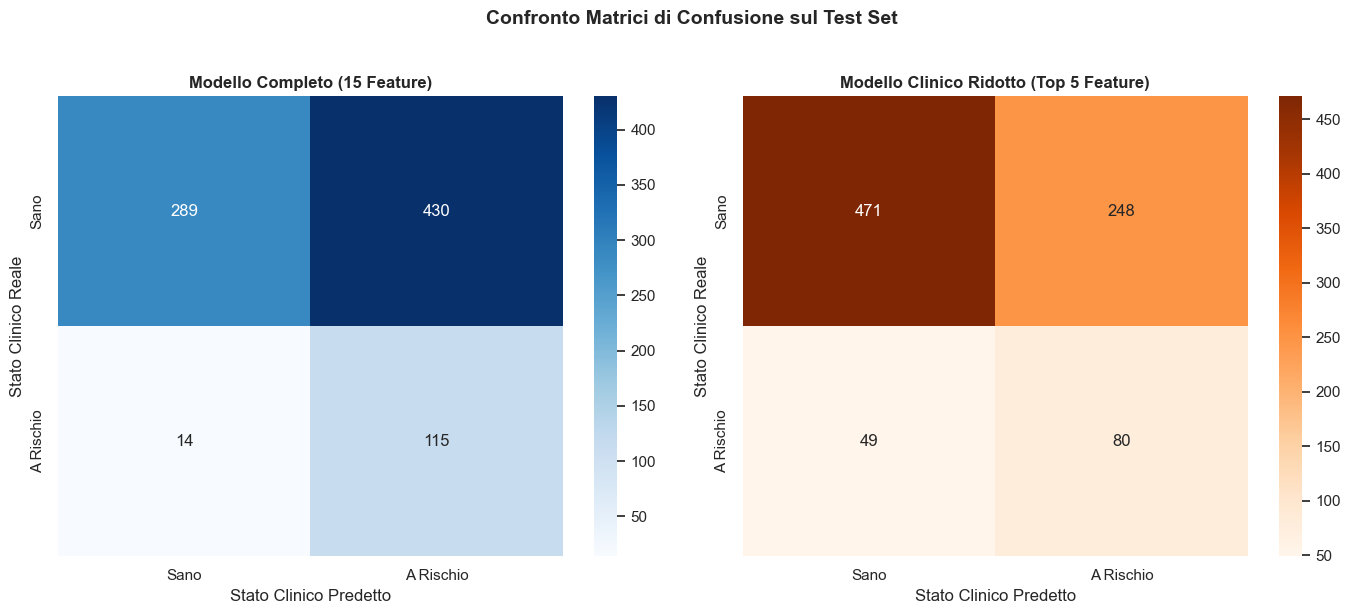

In [9]:
# 5.3. Plot comparativo affiancato delle Matrici di Confusione
from sklearn.metrics import confusion_matrix
cm_completo = confusion_matrix(y_test, predizioni_complete)
cm_ridotto = confusion_matrix(y_test_ridotto, predizioni_ridotte)

figura_cm, assi_cm = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap modello completo
sns.heatmap(cm_completo, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sano', 'A Rischio'], yticklabels=['Sano', 'A Rischio'], ax=assi_cm[0])
assi_cm[0].set_title("Modello Completo (15 Feature)", fontsize=12, fontweight='bold')
assi_cm[0].set_ylabel('Stato Clinico Reale')
assi_cm[0].set_xlabel('Stato Clinico Predetto')

# Heatmap modello ridotto
sns.heatmap(cm_ridotto, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Sano', 'A Rischio'], yticklabels=['Sano', 'A Rischio'], ax=assi_cm[1])
assi_cm[1].set_title("Modello Clinico Ridotto (Top 5 Feature)", fontsize=12, fontweight='bold')
assi_cm[1].set_ylabel('Stato Clinico Reale')
assi_cm[1].set_xlabel('Stato Clinico Predetto')

plt.suptitle("Confronto Matrici di Confusione sul Test Set", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Discussione Critica e Conclusioni Cliniche (Tesina 5)

### 1. Variabili Cliniche che Influenzano Maggiormente la Predizione
Sia l'analisi globale (PFI e SHAP beeswarm) sia l'analisi locale confermano che i principali driver per la predizione del rischio cardiovascolare a 10 anni sono:
- **Età (`age`)**
- **Pressione Sistolica (`sysBP`) e Ipertensione (`prevalentHyp`)**
- **Fumo di sigaretta (`cigsPerDay`/`currentSmoker`)**
- **Colesterolo Totale (`totChol`)**

### 2. Differenze di Interpretabilità tra i Modelli Utilizzati
- **Regressione Logistica (Miglior Modello)**: Il modello in esame si caratterizza per una struttura lineare e additiva. Il funzionamento si basa sulla somma dei contributi delle singole variabili, escludendo la capacità di catturare interazioni non lineari tra le feature, a meno che queste non vengano esplicitamente codificate in fase di preparazione dei dati.
L'intrinseca interpretabilità e la trasparenza dell'algoritmo derivano dal fatto che i coefficienti esprimono direttamente l'effetto sui log-odds (il logaritmo del rapporto di probabilità). Di conseguenza, i valori di spiegazione calcolati tramite la libreria SHAP (nello specifico con l'estensione LinearExplainer) non costituiscono un'approssimazione, ma corrispondono in modo esatto alla combinazione lineare pesata dei coefficienti del modello stesso.

- **Random Forest, XGBoost, LightGBM (Modelli ad Albero)**: Sono modelli non lineari complessi (black-box). Catturano automaticamente le interazioni non lineari e le soglie (es. l'effetto congiunto di fumo ed età). Per essere interpretati richiedono spiegazioni post-hoc come **SHAP TreeExplainer**. L'interpretazione globale è meno diretta della regressione logistica e può risentire di overfitting sui dati sintetici di SMOTE.

- **SVM (Support Vector Machine)**: Utilizzando un kernel non lineare (RBF), la decisione avviene in uno spazio a dimensioni infinite, rendendo il modello completamente opaco. Richiede l'uso di **SHAP KernelExplainer**, che è un metodo perturbativo basato su campionamento, computazionalmente molto costoso ed approssimato.

### 3. Plausibilità Clinica dei Risultati
I risultati emersi sono altamente coerenti con la letteratura medica e le linee guida cardiologiche internazionali:

- L'ipertensione (`sysBP` elevato) e il fumo sono riconosciuti come i due principali fattori di rischio modificabili per l'aterosclerosi coronarica.

- Il fatto che la regressione logistica con SMOTE e class weights superi i modelli ad albero in termini di Recall clinica dimostra che una relazione lineare robusta e regolarizzata, incentrata sulla sensibilità, è preferibile in ambito di screening clinico, dove l'obiettivo primario è non perdere alcun paziente a rischio (falsi negativi) a costo di tollerare alcuni falsi allarmi (falsi positivi).

### 4. Possibili Bias e Limiti del Dataset

- **Bias di Coorte Storica**: Il Framingham Heart Study è iniziato nel 1948 in Massachusetts su una coorte di soggetti quasi esclusivamente caucasici e di classe media. Questo introduce un forte bias demografico: i risultati e le equazioni di rischio potrebbero non generalizzare correttamente su popolazioni etnicamente e geneticamente diverse o con stili di vita moderni.

- **Bias Temporale**: La medicina cardiovascolare potrebbero essere cambiate radicalmente dagli anni '50. Un modello addestrato su dati storici potrebbe sovrastimare il rischio per pazienti moderni.

- **Sbilanciamento delle Classi**: Solo il ~15% dei soggetti sviluppa CHD a 10 anni. Senza correzioni metodologiche (SMOTE sul train e class weights), i classificatori tendono a massimizzare l'accuratezza banale predicendo sempre la classe maggioritaria (sani), azzerando la Recall clinica.

- **Dati Mancanti e Imputazione**: Il dataset originale contiene record con valori nulli. Sebbene l'imputazione KNN prevenga la perdita di dati, introduce un bias di stima basato sui vicini più prossimi, che potrebbe alterare leggermente la varianza reale delle feature cliniche.